<a href="https://colab.research.google.com/github/bioinformaticswoman/Breast-Cancer-Drug-Discovery-Model/blob/main/COBRApy_Flux_Balance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##Block 1
%pip install cobra escher pandas matplotlib numpy -q

import cobra
import escher
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("COBRApy version:", cobra.__version__)
print("Libraries installed and imported successfully.")

COBRApy version: 0.31.1
Libraries installed and imported successfully.


In [ ]:
##Block 2
from cobra.io import load_model

# Use a Synechocystis sp. PCC 6803 model available from BiGG
model_id = "iJN678"

try:
    model = load_model(model_id)

    print("Model loaded successfully!")
    print("Model used:", model_id)
    print("Organism: Synechocystis sp. PCC 6803")
    print()
    print("Number of reactions:", len(model.reactions))
    print("Number of metabolites:", len(model.metabolites))
    print("Number of genes:", len(model.genes))

except Exception as error:
    print("The model could not be loaded.")
    print("This is usually caused by an internet connection problem or temporary BiGG server issue.")
    print("Error message:")
    print(error)

Output()

Model loaded successfully!
Model used: iJN678
Organism: Synechocystis sp. PCC 6803

Number of reactions: 863
Number of metabolites: 795
Number of genes: 622


In [ ]:
##Block 3
# Save the original objective coefficients so we can restore biomass growth later
baseline_objective_coefficients = {
    reaction.id: reaction.objective_coefficient
    for reaction in model.reactions
    if abs(reaction.objective_coefficient) > 1e-12
}

def restore_baseline_objective(model, objective_coefficients):
    """Restore the original model objective, usually biomass."""
    for reaction in model.reactions:
        reaction.objective_coefficient = 0.0

    for reaction_id, coefficient in objective_coefficients.items():
        model.reactions.get_by_id(reaction_id).objective_coefficient = coefficient

baseline_solution = model.optimize()

print("Baseline FBA status:", baseline_solution.status)
print("Baseline predicted growth rate:", baseline_solution.objective_value)

absolute_fluxes = baseline_solution.fluxes.abs().sort_values(ascending=False)
top_10_flux_reactions = baseline_solution.fluxes.loc[absolute_fluxes.head(10).index]

top_10_flux_dataframe = pd.DataFrame({
    "reaction_id": top_10_flux_reactions.index,
    "reaction_name": [model.reactions.get_by_id(reaction_id).name for reaction_id in top_10_flux_reactions.index],
    "flux": top_10_flux_reactions.values,
    "absolute_flux": top_10_flux_reactions.abs().values
})

top_10_flux_dataframe

Baseline FBA status: optimal
Baseline predicted growth rate: 0.0631499569501507


,reaction_id,reaction_name,flux,absolute_flux
0,EX_h2o_e,H2O exchange,3.437065,3.437065
1,H2Otex,H2O transport via diffusion (extracellular to ...,-3.437065,3.437065
2,CO2tpp,CO2 transporter via diffusion (periplasm),-2.535141,2.535141
3,CO2tex,CO2 transport via diffusion (extracellular to ...,-2.535141,2.535141
4,EX_co2_e,CO2 exchange,2.535141,2.535141
5,CBFC2pp,Cytochrome b6/f complex periplasm,2.015568,2.015568
6,CYO1bpp_syn,"Cytochrome c oxidase, synechocystis (2 protons)",2.015568,2.015568
7,NDH1_2p,NAD(P)H dehydrogenase (plastoquinone-8 & 3 pro...,1.569676,1.569676
8,FNOR,Ferredoxin---NADP+ reductase,-1.567925,1.567925
9,H2Otpp,H2O transport via diffusion (periplasm),-1.421497,1.421497


In [ ]:
##Block 4
terpene_keywords = [
    "terp",
    "dxp",
    "mep",
    "isoprenoid",
    "isopentenyl",
    "dimethylallyl",
    "geranyl",
    "farnesyl",
    "ipdp",
    "dmpp",
    "frdp",
    "grdp"
]

matching_reaction_rows = []

try:
    for reaction in model.reactions:
        reaction_text = " ".join([
            reaction.id.lower(),
            reaction.name.lower(),
            " ".join([metabolite.id.lower() for metabolite in reaction.metabolites]),
            " ".join([metabolite.name.lower() for metabolite in reaction.metabolites])
        ])

        matched_keywords = [keyword for keyword in terpene_keywords if keyword in reaction_text]

        if matched_keywords:
            matching_reaction_rows.append({
                "reaction_id": reaction.id,
                "reaction_name": reaction.name,
                "reaction_equation": reaction.reaction,
                "matched_keywords": ", ".join(matched_keywords)
            })

    terpene_reaction_search_results = pd.DataFrame(matching_reaction_rows)

    if terpene_reaction_search_results.empty:
        print("No terpene-related reactions were found using the selected keywords.")
    else:
        print("Terpene-related reaction search results:")
        display(terpene_reaction_search_results)

except Exception as search_error:
    print("Reaction search failed:", search_error)


matching_metabolite_rows = []

try:
    for metabolite in model.metabolites:
        metabolite_text = " ".join([
            metabolite.id.lower(),
            metabolite.name.lower()
        ])

        matched_keywords = [keyword for keyword in terpene_keywords if keyword in metabolite_text]

        if matched_keywords:
            matching_metabolite_rows.append({
                "metabolite_id": metabolite.id,
                "metabolite_name": metabolite.name,
                "formula": metabolite.formula,
                "compartment": metabolite.compartment,
                "matched_keywords": ", ".join(matched_keywords)
            })

    terpene_metabolite_search_results = pd.DataFrame(matching_metabolite_rows)

    if terpene_metabolite_search_results.empty:
        print("No terpene-related metabolites were found using the selected keywords.")
    else:
        print("Terpene-related metabolite search results:")
        display(terpene_metabolite_search_results)

except Exception as search_error:
    print("Metabolite search failed:", search_error)

Terpene-related reaction search results:


,reaction_id,reaction_name,reaction_equation,matched_keywords
0,DXPRIi,1-deoxy-D-xylulose reductoisomerase,dxyl5p_c + h_c + nadph_c --> 2me4p_c + nadp_c,dxp
1,DXPS,1-deoxy-D-xylulose 5-phosphate synthase,g3p_c + h_c + pyr_c --> co2_c + dxyl5p_c,dxp
2,DMPPS_syn,1-hydroxy-2-methyl-2-(E)-butenyl 4-diphosphate...,h2mb4p_c + h_c + nadph_c --> dmpp_c + h2o_c + ...,"dimethylallyl, dmpp"
3,IPDDI,Isopentenyl-diphosphate D-isomerase,ipdp_c <=> dmpp_c,"isopentenyl, dimethylallyl, ipdp, dmpp"
4,IPDPS_syn,1-hydroxy-2-methyl-2-(E)-butenyl 4-diphosphate...,h2mb4p_c + h_c + nadph_c --> h2o_c + ipdp_c + ...,"isopentenyl, ipdp"
5,FRTT,Farnesyltranstransferase,frdp_c + ipdp_c --> ggdp_c + ppi_c,"isopentenyl, geranyl, farnesyl, ipdp, frdp"
6,GRTT,Geranyltranstransferase,grdp_c + ipdp_c --> frdp_c + ppi_c,"isopentenyl, geranyl, farnesyl, ipdp, frdp, grdp"
7,HEMEOS,Heme O synthase,frdp_c + h2o_c + pheme_c --> hemeO_c + ppi_c,"farnesyl, frdp"
8,MEPCT,2-C-methyl-D-erythritol 4-phosphate cytidylylt...,2me4p_c + ctp_c + h_c --> 4c2me_c + ppi_c,mep
9,DPPS,Decaprenyl synthase,frdp_c + 7.0 ipdp_c --> decdp_c + 7.0 ppi_c,"isopentenyl, farnesyl, ipdp, frdp"


Terpene-related metabolite search results:


,metabolite_id,metabolite_name,formula,compartment,matched_keywords
0,dmpp_c,Dimethylallyl diphosphate,C5H9O7P2,c,"dimethylallyl, dmpp"
1,grdp_c,Geranyl diphosphate,C10H17O7P2,c,"geranyl, grdp"
2,frdp_c,Farnesyl diphosphate,C15H25O7P2,c,"farnesyl, frdp"
3,ipdp_c,Isopentenyl diphosphate,C5H9O7P2,c,"isopentenyl, ipdp"
4,ggdp_c,Geranylgeranyl diphosphate C20H33O7P2,C20H33O7P2,c,geranyl


In [ ]:
##Block 5
def find_best_terpene_proxy_metabolite(model):
    """Find the best available terpene precursor metabolite dynamically."""
    priority_keywords = [
        "isopentenyl diphosphate",
        "isopentenyl",
        "ipdp",
        "dimethylallyl diphosphate",
        "dimethylallyl",
        "dmpp",
        "farnesyl diphosphate",
        "farnesyl",
        "frdp",
        "geranyl diphosphate",
        "geranyl",
        "grdp"
    ]

    for keyword in priority_keywords:
        matches = [
            metabolite for metabolite in model.metabolites
            if keyword in metabolite.id.lower() or keyword in metabolite.name.lower()
        ]

        if matches:
            cytosolic_matches = [
                metabolite for metabolite in matches
                if metabolite.compartment == "c" or metabolite.id.endswith("_c")
            ]

            if cytosolic_matches:
                return cytosolic_matches[0]

            return matches[0]

    return None


try:
    terpene_proxy_metabolite = find_best_terpene_proxy_metabolite(model)

    if terpene_proxy_metabolite is None:
        raise ValueError("No suitable terpene precursor metabolite was found.")

    terpene_demand_reaction_id = f"DM_{terpene_proxy_metabolite.id}"

    if terpene_demand_reaction_id in model.reactions:
        terpene_output_reaction = model.reactions.get_by_id(terpene_demand_reaction_id)
    else:
        terpene_output_reaction = model.add_boundary(
            terpene_proxy_metabolite,
            type="demand",
            reaction_id=terpene_demand_reaction_id
        )

    terpene_output_reaction.lower_bound = 0.0
    terpene_output_reaction.upper_bound = 1000.0

    model.objective = terpene_output_reaction
    terpene_objective_solution = model.optimize()

    print("Selected terpene proxy metabolite:")
    print(terpene_proxy_metabolite.id, "-", terpene_proxy_metabolite.name)

    print("\nTerpene proxy output reaction:")
    print(terpene_output_reaction.id, ":", terpene_output_reaction.reaction)

    print("\nBaseline growth objective value:", baseline_solution.objective_value)
    print("Maximum terpene proxy flux:", terpene_objective_solution.objective_value)

    print("\nImportant note:")
    print("The baseline value is predicted growth, while the new value is terpene proxy flux.")
    print("They are different biological objectives and should not be interpreted as the same unit of performance.")

except Exception as objective_error:
    print("Could not set terpene objective:", objective_error)
    raise

Selected terpene proxy metabolite:
ipdp_c - Isopentenyl diphosphate

Terpene proxy output reaction:
DM_ipdp_c : ipdp_c --> 

Baseline growth objective value: 0.0631499569501507
Maximum terpene proxy flux: 0.6167021276595741

Important note:
The baseline value is predicted growth, while the new value is terpene proxy flux.
They are different biological objectives and should not be interpreted as the same unit of performance.


In [ ]:
##Block 6a
from cobra.flux_analysis import single_gene_deletion

# Make sure the model objective is terpene proxy production
model.objective = terpene_output_reaction

wildtype_terpene_flux = model.optimize().objective_value

print("Wildtype terpene proxy flux:", wildtype_terpene_flux)
print("Running terpene-focused single gene deletion analysis...")
print("This may still take a few minutes, but it is simpler than the previous version.")

terpene_gene_deletion_results = single_gene_deletion(
    model,
    gene_list=list(model.genes),
    processes=1
)

def extract_gene_id(ids_value):
    if isinstance(ids_value, (set, frozenset, list, tuple)):
        return list(ids_value)[0]
    return str(ids_value)

terpene_gene_deletion_results["gene_id"] = terpene_gene_deletion_results["ids"].apply(extract_gene_id)

terpene_gene_deletion_results = terpene_gene_deletion_results.rename(
    columns={"growth": "terpene_flux_after_knockout"}
)

terpene_gene_deletion_results["terpene_flux_change"] = (
    terpene_gene_deletion_results["terpene_flux_after_knockout"] - wildtype_terpene_flux
)

terpene_gene_deletion_results["terpene_flux_percent_change"] = (
    100 * terpene_gene_deletion_results["terpene_flux_change"] / abs(wildtype_terpene_flux)
    if abs(wildtype_terpene_flux) > 1e-12
    else np.nan
)

# Keep only knockouts that improve terpene flux
improved_terpene_knockouts = terpene_gene_deletion_results[
    terpene_gene_deletion_results["terpene_flux_change"] > 1e-9
].copy()

improved_terpene_knockouts = improved_terpene_knockouts.sort_values(
    by="terpene_flux_change",
    ascending=False
).reset_index(drop=True)

print("Number of knockouts that increased terpene proxy flux:", len(improved_terpene_knockouts))

display(improved_terpene_knockouts.head(20))

Wildtype terpene proxy flux: 0.6167021276595731
Running terpene-focused single gene deletion analysis...
This may still take a few minutes, but it is simpler than the previous version.
Number of knockouts that increased terpene proxy flux: 0


,ids,terpene_flux_after_knockout,status,gene_id,terpene_flux_change,terpene_flux_percent_change


In [ ]:
##Block 6b
def calculate_growth_after_gene_knockout(gene_id):
    """
    Calculate growth after knocking out one gene.
    The original biomass objective is restored inside the temporary model context.
    """
    try:
        with model:
            model.genes.get_by_id(gene_id).knock_out()
            restore_baseline_objective(model, baseline_objective_coefficients)
            knockout_growth_solution = model.optimize()
            return knockout_growth_solution.objective_value
    except Exception:
        return np.nan


print("Checking growth for terpene-improving knockout candidates...")

# First choice: genes that increased terpene proxy flux
candidate_knockouts = improved_terpene_knockouts.copy()

if candidate_knockouts.empty:
    print("No knockouts increased terpene proxy flux.")
    print("Using the best available knockout candidates ranked by terpene proxy flux instead.")

    candidate_knockouts = terpene_gene_deletion_results.sort_values(
        by="terpene_flux_after_knockout",
        ascending=False
    ).head(50).copy()

    candidate_knockouts["candidate_category"] = "Best available growth-compatible candidate"

else:
    candidate_knockouts["candidate_category"] = "Improves terpene flux"


# Calculate growth only for selected candidate genes
candidate_knockouts["growth_rate_after_knockout"] = candidate_knockouts["gene_id"].apply(
    calculate_growth_after_gene_knockout
)

# Keep only candidates that still allow growth
growth_compatible_knockouts = candidate_knockouts[
    candidate_knockouts["growth_rate_after_knockout"] > 0.01
].copy()


# If improved candidates do not preserve growth, use fallback candidates
if growth_compatible_knockouts.empty and not terpene_gene_deletion_results.empty:
    print("No terpene-improving knockout preserved growth above 0.01.")
    print("Checking fallback candidates ranked by terpene proxy flux...")

    fallback_knockouts = terpene_gene_deletion_results.sort_values(
        by="terpene_flux_after_knockout",
        ascending=False
    ).head(50).copy()

    fallback_knockouts["candidate_category"] = "Best available growth-compatible candidate"

    fallback_knockouts["growth_rate_after_knockout"] = fallback_knockouts["gene_id"].apply(
        calculate_growth_after_gene_knockout
    )

    growth_compatible_knockouts = fallback_knockouts[
        fallback_knockouts["growth_rate_after_knockout"] > 0.01
    ].copy()


# Create final plot-ready top 10 table
if growth_compatible_knockouts.empty:
    print("No growth-compatible knockout candidates were found.")
    print("This may mean the model is highly sensitive to these gene deletions under the selected objective.")

    top_10_terpene_knockouts = pd.DataFrame(
        columns=[
            "gene_id",
            "candidate_category",
            "status",
            "growth_rate_after_knockout",
            "terpene_flux_after_knockout",
            "terpene_flux_change",
            "terpene_flux_percent_change"
        ]
    )

else:
    if "Improves terpene flux" in growth_compatible_knockouts["candidate_category"].values:
        top_10_terpene_knockouts = growth_compatible_knockouts.sort_values(
            by="terpene_flux_change",
            ascending=False
        ).head(10)
    else:
        top_10_terpene_knockouts = growth_compatible_knockouts.sort_values(
            by="terpene_flux_after_knockout",
            ascending=False
        ).head(10)

    top_10_terpene_knockouts = top_10_terpene_knockouts[
        [
            "gene_id",
            "candidate_category",
            "status",
            "growth_rate_after_knockout",
            "terpene_flux_after_knockout",
            "terpene_flux_change",
            "terpene_flux_percent_change"
        ]
    ].reset_index(drop=True)

    print("Final plot-ready knockout table:")
    display(top_10_terpene_knockouts)

Checking growth for terpene-improving knockout candidates...
No knockouts increased terpene proxy flux.
Using the best available knockout candidates ranked by terpene proxy flux instead.
Final plot-ready knockout table:


,gene_id,candidate_category,status,growth_rate_after_knockout,terpene_flux_after_knockout,terpene_flux_change,terpene_flux_percent_change
0,sll0550,Best available growth-compatible candidate,optimal,0.06315,0.616702,1.332268e-14,2.160310e-12
1,psbD2,Best available growth-compatible candidate,optimal,0.06315,0.616702,9.436896e-15,1.530219e-12
2,sll1054,Best available growth-compatible candidate,optimal,0.06315,0.616702,4.996004e-15,8.101162e-13
3,upp,Best available growth-compatible candidate,optimal,0.06315,0.616702,4.773959e-15,7.741110e-13
4,livF,Best available growth-compatible candidate,optimal,0.06315,0.616702,4.551914e-15,7.381058e-13
5,bvdR,Best available growth-compatible candidate,optimal,0.06315,0.616702,4.551914e-15,7.381058e-13
6,yibO,Best available growth-compatible candidate,optimal,0.06315,0.616702,4.551914e-15,7.381058e-13
7,slr2001,Best available growth-compatible candidate,optimal,0.06315,0.616702,4.551914e-15,7.381058e-13
8,manA,Best available growth-compatible candidate,optimal,0.06315,0.616702,4.551914e-15,7.381058e-13
9,psbZ,Best available growth-compatible candidate,optimal,0.06315,0.616702,4.551914e-15,7.381058e-13


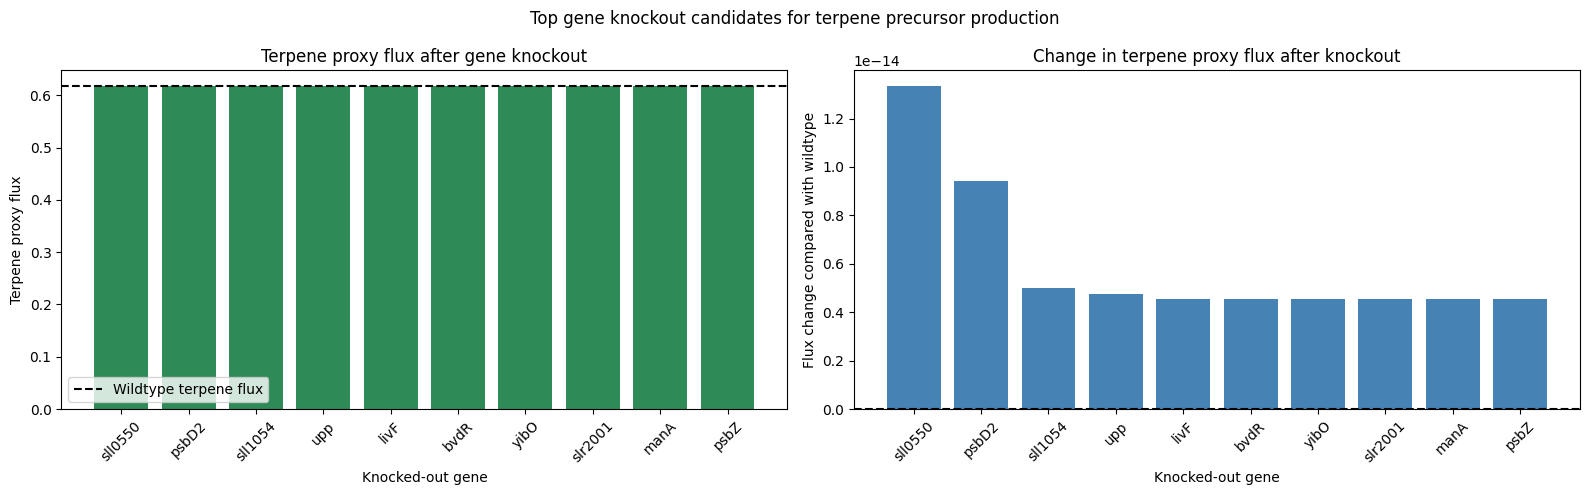

Candidate category:
Best available growth-compatible candidate


In [ ]:
##Block 7
if top_10_terpene_knockouts.empty:
    print("No plot was generated because no growth-compatible knockout candidates were available.")
    print("Biological interpretation:")
    print("Under the current model constraints, the tested single-gene knockouts did not produce usable terpene-focused candidates.")
    print("You may need to test reaction knockouts, change nutrient/light constraints, or add a specific terpene production reaction.")

else:
    plot_dataframe = top_10_terpene_knockouts.copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].bar(
        plot_dataframe["gene_id"],
        plot_dataframe["terpene_flux_after_knockout"],
        color="seagreen"
    )
    axes[0].axhline(
        wildtype_terpene_flux,
        color="black",
        linestyle="--",
        label="Wildtype terpene flux"
    )
    axes[0].set_xlabel("Knocked-out gene")
    axes[0].set_ylabel("Terpene proxy flux")
    axes[0].set_title("Terpene proxy flux after gene knockout")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].legend()

    axes[1].bar(
        plot_dataframe["gene_id"],
        plot_dataframe["terpene_flux_change"],
        color="steelblue"
    )
    axes[1].axhline(
        0,
        color="black",
        linestyle="--"
    )
    axes[1].set_xlabel("Knocked-out gene")
    axes[1].set_ylabel("Flux change compared with wildtype")
    axes[1].set_title("Change in terpene proxy flux after knockout")
    axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle("Top gene knockout candidates for terpene precursor production")
    plt.tight_layout()
    plt.show()

    print("Candidate category:")
    print(plot_dataframe["candidate_category"].iloc[0])

In [ ]:
##Block 8
from google.colab import files

output_csv_filename = "synechocystis_terpene_gene_knockout_results.csv"

top_10_terpene_knockouts.to_csv(output_csv_filename, index=False)

print("Saved results to:", output_csv_filename)
print("\nFinal interpretation:")
print("Genes with positive terpene_flux_change are predicted to increase terpene proxy flux.")
print("Genes with growth_rate_after_knockout > 0.01 are predicted to preserve minimal growth.")
print("Strong candidates balance improved terpene precursor flux with acceptable growth.")

files.download(output_csv_filename)

Saved results to: synechocystis_terpene_gene_knockout_results.csv

Final interpretation:
Genes with positive terpene_flux_change are predicted to increase terpene proxy flux.
Genes with growth_rate_after_knockout > 0.01 are predicted to preserve minimal growth.
Strong candidates balance improved terpene precursor flux with acceptable growth.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
from google.colab import files

input_notebook_name = "COBRApy_Flux_Balance.ipynb"
cleaned_notebook_name = "COBRApy_Flux_Balance_cleaned.ipynb"

try:
    with open(input_notebook_name, "r", encoding="utf-8") as notebook_file:
        notebook_data = json.load(notebook_file)

    # Remove problematic widget metadata
    if "metadata" in notebook_data and "widgets" in notebook_data["metadata"]:
        del notebook_data["metadata"]["widgets"]

    # Remove saved outputs from all code cells
    for cell in notebook_data.get("cells", []):
        if cell.get("cell_type") == "code":
            cell["outputs"] = []
            cell["execution_count"] = None

    with open(cleaned_notebook_name, "w", encoding="utf-8") as cleaned_file:
        json.dump(notebook_data, cleaned_file, indent=1)

    print("Cleaned notebook created successfully:")
    print(cleaned_notebook_name)
    print()
    print("Upload this cleaned file to GitHub.")

    files.download(cleaned_notebook_name)

except FileNotFoundError:
    print("Notebook file not found.")
    print("In Colab, first go to File > Download > Download .ipynb, then upload that .ipynb file into Colab's file panel.")
    print("Make sure the filename matches:", input_notebook_name)

except Exception as error:
    print("Something went wrong while cleaning the notebook:")
    print(error)

Notebook file not found.
In Colab, first go to File > Download > Download .ipynb, then upload that .ipynb file into Colab's file panel.
Make sure the filename matches: COBRApy_Flux_Balance.ipynb
